In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [6]:
DATA_PATH = "train.csv"
df = pd.read_csv(DATA_PATH)

df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [7]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (891, 12)

Missing values per column:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
missing_count,0,0,0,0,0,177,0,0,0,0,687,2



Duplicate rows: 0


In [10]:
target_col = "Survived"

print(df[target_col].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


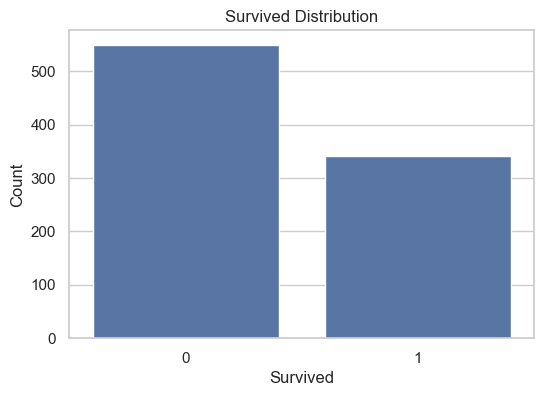

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Survived Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

In [12]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [13]:
df_fe = df.copy()

# Handle missing values
df_fe["Age"] = df_fe["Age"].fillna(df_fe["Age"].median())

# Create new engineered columns
df_fe["FamilySize"] = df_fe["SibSp"] + df_fe["Parch"] + 1
df_fe["IsAlone"] = (df_fe["FamilySize"] == 1).astype(int)
df_fe["FarePerPerson"] = df_fe["Fare"] / df_fe["FamilySize"]

# Extract title from Name
df_fe["Title"] = df_fe["Name"].str.extract(r",\s*([^\.]+)\.", expand=False)

df_fe[["Name", "FamilySize", "IsAlone", "FarePerPerson", "Title"]].head(10)

,Name,FamilySize,IsAlone,FarePerPerson,Title
0,"Braund, Mr. Owen Harris",2,0,3.62500,Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,0,35.64165,Mrs
2,"Heikkinen, Miss. Laina",1,1,7.92500,Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2,0,26.55000,Mrs
4,"Allen, Mr. William Henry",1,1,8.05000,Mr
5,"Moran, Mr. James",1,1,8.45830,Mr
6,"McCarthy, Mr. Timothy J",1,1,51.86250,Mr
7,"Palsson, Master. Gosta Leonard",5,0,4.21500,Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",3,0,3.71110,Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",2,0,15.03540,Mrs


In [14]:
df_fe["Fare_per_person"] = df_fe["Fare"] / (df_fe["SibSp"] + df_fe["Parch"] + 1)

df_fe[["Fare","SibSp","Parch","Fare_per_person"]].head(10)

,Fare,SibSp,Parch,Fare_per_person
0,7.2500,1,0,3.62500
1,71.2833,1,0,35.64165
2,7.9250,0,0,7.92500
3,53.1000,1,0,26.55000
4,8.0500,0,0,8.05000
5,8.4583,0,0,8.45830
6,51.8625,0,0,51.86250
7,21.0750,3,1,4.21500
8,11.1333,0,2,3.71110
9,30.0708,1,0,15.03540


In [15]:
def fare_per_person(fare, sibsp, parch):
    """Calculate fare per person in the family."""
    family_size = sibsp + parch + 1
    return fare / family_size

cols = {"Fare","SibSp","Parch"}

if cols.issubset(set(df_fe.columns)):
    df_fe["fare_per_person"] = fare_per_person(
        df_fe["Fare"],
        df_fe["SibSp"],
        df_fe["Parch"]
    )
    
    display(df_fe[["Fare","SibSp","Parch","fare_per_person"]].head(10))
else:
    print("Required columns not found. Skipping fare_per_person feature.")

,Fare,SibSp,Parch,fare_per_person
0,7.2500,1,0,3.62500
1,71.2833,1,0,35.64165
2,7.9250,0,0,7.92500
3,53.1000,1,0,26.55000
4,8.0500,0,0,8.05000
5,8.4583,0,0,8.45830
6,51.8625,0,0,51.86250
7,21.0750,3,1,4.21500
8,11.1333,0,2,3.71110
9,30.0708,1,0,15.03540


In [16]:
if "Ticket" in df_fe.columns:
    top_k = 20
    top_items = df_fe["Ticket"].value_counts().head(top_k).index
    df_fe["Ticket_reduced"] = np.where(df_fe["Ticket"].isin(top_items), df_fe["Ticket"], "Other")
    print("Unique Ticket:", df_fe["Ticket"].nunique())
    print("Unique Ticket_reduced:", df_fe["Ticket_reduced"].nunique())
    df_fe[["Ticket","Ticket_reduced"]].head(10)
else:
    print("Ticket column not found.")

Unique Ticket: 681
Unique Ticket_reduced: 21


In [17]:
df_fe["fare_tier"] = pd.cut(
    df_fe["Fare"],
    bins=[0, 8, 15, 32, np.inf],
    labels=["low","medium","high","very_high"]
)

df_fe[["Fare","fare_tier"]].head(10)

,Fare,fare_tier
0,7.2500,low
1,71.2833,very_high
2,7.9250,low
3,53.1000,very_high
4,8.0500,medium
5,8.4583,medium
6,51.8625,very_high
7,21.0750,high
8,11.1333,medium
9,30.0708,high


In [18]:
drop_cols = [
    "PassengerId", "Name", "Ticket", "Cabin"
]

# keep only columns that exist (safe for future versions of the dataset)
drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (891, 15)
y shape: (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,FarePerPerson,Title,Fare_per_person,fare_per_person,Ticket_reduced,fare_tier
0,3,male,22.0,1,0,7.2500,S,2,0,3.62500,Mr,3.62500,3.62500,Other,low
1,1,female,38.0,1,0,71.2833,C,2,0,35.64165,Mrs,35.64165,35.64165,Other,very_high
2,3,female,26.0,0,0,7.9250,S,1,1,7.92500,Miss,7.92500,7.92500,Other,low
3,1,female,35.0,1,0,53.1000,S,2,0,26.55000,Mrs,26.55000,26.55000,Other,very_high
4,3,male,35.0,0,0,8.0500,S,1,1,8.05000,Mr,8.05000,8.05000,Other,medium


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

X_train.head()

Train size: (712, 15)
Test size: (179, 15)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,FarePerPerson,Title,Fare_per_person,fare_per_person,Ticket_reduced,fare_tier
692,3,male,28.0,0,0,56.4958,S,1,1,56.4958,Mr,56.4958,56.4958,1601,very_high
481,2,male,28.0,0,0,0.0000,S,1,1,0.0000,Mr,0.0000,0.0000,Other,NaN
527,1,male,28.0,0,0,221.7792,S,1,1,221.7792,Mr,221.7792,221.7792,Other,very_high
855,3,female,18.0,0,1,9.3500,S,2,0,4.6750,Mrs,4.6750,4.6750,Other,medium
801,2,female,31.0,1,1,26.2500,S,3,0,8.7500,Mrs,8.7500,8.7500,Other,high


In [20]:
# Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model


Categorical columns: ['Sex', 'Embarked', 'Title', 'Ticket_reduced', 'fare_tier']
Numeric columns: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Fare_per_person', 'fare_per_person']


C:\Users\moham\AppData\Local\Temp\ipykernel_6980\945966939.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

In [21]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8156

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.76      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



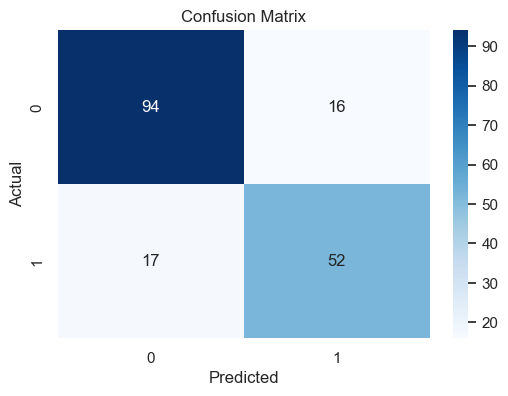

In [22]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)

,feature,importance
47,Age,0.169339
15,Title_Mr,0.109236
50,Fare,0.083175
55,fare_per_person,0.079925
54,Fare_per_person,0.079516
0,Sex_female,0.078992
53,FarePerPerson,0.077808
1,Sex_male,0.073281
46,Pclass,0.031667
51,FamilySize,0.026906


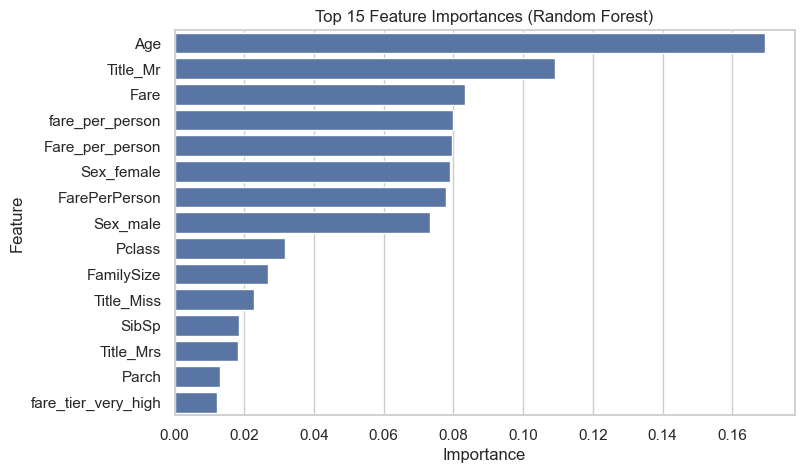

In [24]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [26]:
from sklearn.feature_selection import SelectFromModel

# Build a new pipeline that selects features based on RF importances
selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"  # keep features above the median importance
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)

print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs))


Accuracy (with feature selection): 0.8101

Classification Report (with feature selection):
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       110
           1       0.75      0.77      0.76        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

